In [41]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import r2_score , mean_squared_error , root_mean_squared_error
import warnings 
warnings.filterwarnings('ignore')

In [42]:
data = pd.read_csv('Salary_Data.csv')
data.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [43]:
data = pd.read_csv('Social_Network_Ads.csv')
data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [44]:
x = data.iloc[: , :-1]
y = data.iloc[:, 1]
x_train , x_test , y_train , y_test = train_test_split(x , y , train_size = 0.8 , random_state = 10 )

In [45]:
x = data.iloc[ : , [2 , 3]].values
y = data.iloc[: , 4].values
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size= 0.2 , random_state= 10 )

In [46]:
from sklearn.preprocessing import StandardScaler 
sc_x = StandardScaler()
x_train = sc_x.fit_transform(x_train)
x_test = sc_x.transform(x_test)

In [47]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(x_train , y_train)
y_pred = classifier.predict(x_test)

In [48]:
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,precision_score,f1_score,roc_auc_score
cm = confusion_matrix(y_test, y_pred)
cm

array([[48,  4],
       [ 5, 23]])

In [49]:
accuracy_score_ =accuracy_score(y_test, y_pred)
 
recall_score_=recall_score(y_test, y_pred)
precision_score_=precision_score(y_test, y_pred)
f1_score_=f1_score(y_test, y_pred)
print('accuracy_score_',accuracy_score_)
print('recall_score_',recall_score_)
print('precision_score_',precision_score_)
print('f1_score_',f1_score_)

accuracy_score_ 0.8875
recall_score_ 0.8214285714285714
precision_score_ 0.8518518518518519
f1_score_ 0.8363636363636363


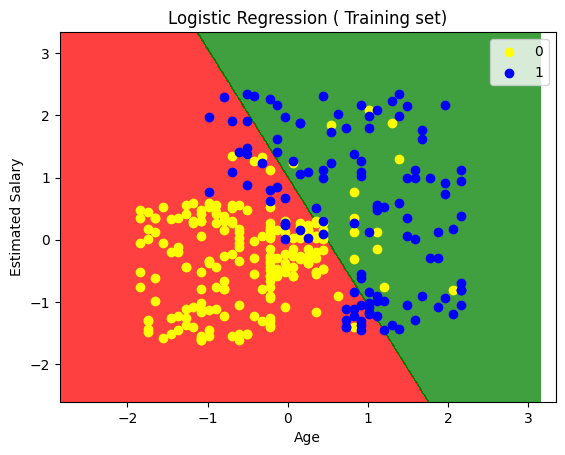

In [50]:
from matplotlib.colors import ListedColormap
X_Set, Y_Set = x_train, y_train
X1, X2 = np.meshgrid(np.arange(start = X_Set[:,0].min() -1, stop = X_Set[:, 0].max() +1, step = 0.01),
                     np.arange(start = X_Set[:,1].min() -1, stop = X_Set[:, 1].max() +1, step = 0.01))
 
 
plt.contourf(X1,X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
 
plt.xlim(X1.min(), X2.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(Y_Set)):
    plt.scatter(X_Set[Y_Set == j, 0], X_Set[Y_Set == j,1],
                c = ListedColormap(('yellow', 'blue'))(i), label = j)
plt.title('Logistic Regression ( Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

In [51]:
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,precision_score,f1_score,roc_auc_score
cm = confusion_matrix(y_test, y_pred)
cm

array([[48,  4],
       [ 5, 23]])